<a href="https://colab.research.google.com/github/chhammet/ST554_HW6/blob/main/cole_hammett_hw_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 6 — ST 554: Big Data with Python
**Author:** Cole Hammett (`chhammet@ncsu.edu`)

This notebook covers two parts:
- **Part I** – SQL queries against the Lahman baseball SQLite database
- **Part II** – Demonstration of the `SLR_slope_simulator` class defined in `SLR_slope_simulator.py`

---
## Part I — More Practice Querying a Database

The [Lahman Baseball Database](http://www.seanlahman.com/baseball-archive/statistics/) contains historical Major League Baseball statistics.

In [25]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
from sklearn import linear_model

print('Libraries imported successfully.')

Libraries imported successfully.


### Loading data





1)  Connected to the database by uploading to Colab

In [26]:
con = sqlite3.connect("/content/lahman_1871-2022.sqlite")

2) Looked at all of the tables in the
database (as a data frame) using `read_sql()` from pandas.

In [27]:

pd.read_sql("SELECT * FROM sqlite_schema WHERE type = 'table';", con)

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


###  Constructing a table of pitching statistics of hall of fame (HoF) pitchers
using a SQL `INNER JOIN` between:

`Pitching` aliased as `p`

`HallOfFame` aliased as `h`

on `playerID`

1) Joined to pull only rows for pitchers in HoF




In [28]:
pitching_raw = pd.read_sql("""
    SELECT p.playerID, p.GS, p.G, p.W, p.L, p.IPouts, p.CG, p.SHO, p.SV
    FROM Pitching AS p
    INNER JOIN HallOfFame AS h ON p.playerID = h.playerID
    WHERE h.inducted = 'Y';
""", con)

2) Summed the requested pitching columns per player: `GS`, `G`, `W`, `L`, `IPouts`, `CG`, `SHO`, `SV`

In [29]:
pitching_stats = (
    pitching_raw
    .groupby('playerID')[['GS', 'G', 'W', 'L', 'IPouts', 'CG', 'SHO', 'SV']]
    .sum()
    .reset_index()
)

print(f'Hall of Fame pitchers found: {len(pitching_stats)}')
pitching_stats.head(10)

Hall of Fame pitchers found: 108


,playerID,GS,G,W,L,IPouts,CG,SHO,SV
0,alexape01,599,696,373,208,15570,437,90,32
1,ansonca01,0,3,0,1,12,0,0,1
2,becklja01,1,1,0,1,12,0,0,0
3,bendech01,334,459,212,127,9051,255,40,34
4,blylebe01,685,692,287,250,14910,242,60,0
5,boggswa01,0,2,0,0,7,0,0,0
6,bresnro01,6,9,4,1,151,3,1,0
7,broutda01,2,4,0,2,69,2,0,0
8,brownmo01,332,481,239,130,9517,271,55,49
9,bunniji01,519,591,224,184,11281,151,40,16


### Creating a table of the *batting* statistics for HoF pitcher
by using a SQL subquery to filter the batting table down to only `playerID`s that appear in both:
* The   `Pitching` table
* The `HallOfFame` table

1) Pulled batting records only for players who are:
    * in the Pitching table (i.e., they actually pitched), AND
    * inducted into the Hall of Fame

In [30]:
batting_raw = pd.read_sql("""
    SELECT b.playerID, b.AB, b.R, b.H, b.HR, b.RBI, b.BB, b.SO
    FROM Batting AS b
    WHERE b.playerID IN (
        SELECT DISTINCT p.playerID
        FROM Pitching AS p
        INNER JOIN HallOfFame AS h ON p.playerID = h.playerID
        WHERE h.inducted = 'Y'
    );
""", con)



3) Summed the batting columns per player: `AB`, `R`, `H`, `HR`, `RBI`, `BB`, `SO`

In [31]:
batting_stats = (
    batting_raw
    .groupby('playerID')[['AB', 'R', 'H', 'HR', 'RBI', 'BB', 'SO']]
    .sum()
    .reset_index()
)

print(f'Hall of Fame pitchers with batting records: {len(batting_stats)}')
batting_stats.head(10)

Hall of Fame pitchers with batting records: 108


,playerID,AB,R,H,HR,RBI,BB,SO
0,alexape01,1810,154,378,11,163.0,77,276.0
1,ansonca01,10281,1999,3435,97,2075.0,984,330.0
2,becklja01,9551,1603,2938,87,1581.0,616,526.0
3,bendech01,1147,102,243,6,116.0,75,143.0
4,blylebe01,451,19,59,0,25.0,5,193.0
5,boggswa01,9180,1513,3010,118,1014.0,1412,745.0
6,bresnro01,4481,682,1252,26,530.0,714,403.0
7,broutda01,6726,1529,2303,107,1301.0,840,238.0
8,brownmo01,1143,93,235,2,74.0,44,199.0
9,bunniji01,1275,82,213,7,75.0,34,362.0


### Joining pitching and batting tables
to generate a single combined table of pitching and batting stats for each HoF pitcher

by joining both `pitching stats` and `batting stats` by `playerID` using `pd.merge()`

1) Merged pitching and batting summaries on playerID using an inner join

In [32]:
combined_df = pd.merge(
    pitching_stats,
    batting_stats,
    on='playerID',
    how='inner'
)

print(f'Combined table shape: {combined_df.shape}')
combined_df.head(10)

Combined table shape: (108, 16)


,playerID,GS,G,W,L,IPouts,CG,SHO,SV,AB,R,H,HR,RBI,BB,SO
0,alexape01,599,696,373,208,15570,437,90,32,1810,154,378,11,163.0,77,276.0
1,ansonca01,0,3,0,1,12,0,0,1,10281,1999,3435,97,2075.0,984,330.0
2,becklja01,1,1,0,1,12,0,0,0,9551,1603,2938,87,1581.0,616,526.0
3,bendech01,334,459,212,127,9051,255,40,34,1147,102,243,6,116.0,75,143.0
4,blylebe01,685,692,287,250,14910,242,60,0,451,19,59,0,25.0,5,193.0
5,boggswa01,0,2,0,0,7,0,0,0,9180,1513,3010,118,1014.0,1412,745.0
6,bresnro01,6,9,4,1,151,3,1,0,4481,682,1252,26,530.0,714,403.0
7,broutda01,2,4,0,2,69,2,0,0,6726,1529,2303,107,1301.0,840,238.0
8,brownmo01,332,481,239,130,9517,271,55,49,1143,93,235,2,74.0,44,199.0
9,bunniji01,519,591,224,184,11281,151,40,16,1275,82,213,7,75.0,34,362.0


---
## Part II — SLR Slope Simulator Class (Demonstration)

The full class definition lives in `SLR_slope_simulator.py` (submitted alongside this notebook).

Imported here to run all required demonstrations.

**Model:** $Y_i = \beta_0 + \beta_1 x_i + \varepsilon_i$, $\;\varepsilon_i \overset{iid}{\sim} N(0, \sigma^2)$

The class simulates many datasets from this model, fits OLS on each one, and stores the slope estimates — building up an empirical sampling distribution of $\hat{\beta}_1$.

### Importing the SLR_slope_simulator class from our .py file

In [33]:
from SLR_slope_simulator import SLR_slope_simulator

### Demonstrating functionalities

1) Built x, linspace(0, 10, 11) gives [0, 1, ..., 10]; repeat 3 times for n=33

In [34]:
x_vals = np.array(list(np.linspace(start=0, stop=10, num=11)) * 3)

2) Created an instance with given parameters:
    * $\beta_0 = 12$, $\beta_1 = 2$, $\sigma = 1$, `seed = 10`
    * $x$ = integers $0, 1, \ldots, 10$ repeated 3 times ($n = 33$ observations)

In [35]:
sim = SLR_slope_simulator(
    beta_0=12,
    beta_1=2,
    x=x_vals,
    sigma=1,
    seed=10
)

3) Called `plot_sampling_distribution()` method BEFORE running simulations to check if error message prints

In [36]:
sim.plot_sampling_distribution()

Error: run_simulations() must be called first before plotting.


4) Ran 10,000 simulations by calling the `generate_data()` and `fit_slope()` methods in a loop and storing OLS slope estimate in sim.slopes

In [37]:
sim.run_simulations(10000)

print(f'Simulations complete. {len(sim.slopes)} slope estimates stored in sim.slopes.')

Simulations complete. 10000 slope estimates stored in sim.slopes.


5) Plotted the generated sampling distribution of the slope estimator (with histogram centered on 2, a provided parameter)

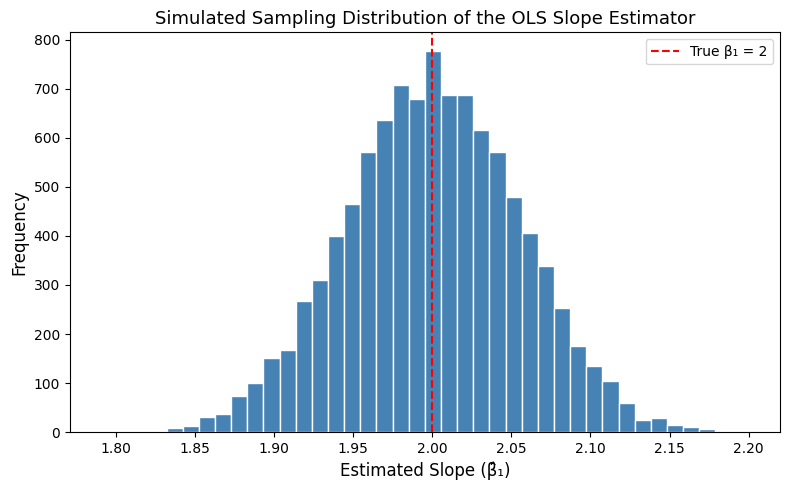

In [38]:
sim.plot_sampling_distribution()

6. Approximated the two-sided probability of the slope being larger than 2.1

In [39]:
prob_two_sided = sim.find_prob(value=2.1, sided='two-sided')
print(f'Approximate two-sided probability for slope > 2.1: {prob_two_sided:.4f}')

Approximate two-sided probability for slope > 2.1: 0.0704


7) Printed the slopes stored in the `slopes` attribute as a numpy array of 10,000 OLS slope estimates

In [40]:
print('sim.slopes attribute:')
print(sim.slopes)

sim.slopes attribute:
[2.0239168  1.99560551 2.04249093 ... 1.93451109 2.01445559 2.07173587]


### Interpreting the two-sided probability

The value printed above approximates the probability of observing a slope estimate **at least as extreme as 2.1** when the true slope is $\beta_1 = 2$.  

This is the same thing as a **p-value** in a hypothesis test. If we were testing:

$$H_0: \beta_1 = 2 \quad \text{vs} \quad H_a: \beta_1 \neq 2$$

then the two-sided probability gives us the fraction of simulated slopes that fall **as far** from the true value (in either direction) as our observed value of 2.1.  

A small probability means that a slope of 2.1 would be **unusual** under the null model. This is how simulation is used for inference: the empirical sampling distribution built is what theory describes analytically (a Normal distribution centered at $\beta_1$ with variance $\sigma^2 / S_{xx}$).